In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

## MC null

In [2]:
mc_size = [30, 50, 75]
mc_res = {}
for size in mc_size:
    dfs = []
    files = Path(f'/mnt/gs21/scratch/yuanhao5/icepop_null_mc-{size}').rglob('metacell*.csv')
    files = [str(file) for file in files]
    for file in tqdm(files, total=len(files)):
        df = pd.read_csv(file, header=0, index_col=0, usecols=["metacell", "p"])
        dfs.append(df)
    mc_res[size] = np.asarray(pd.concat(dfs, axis=1), np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

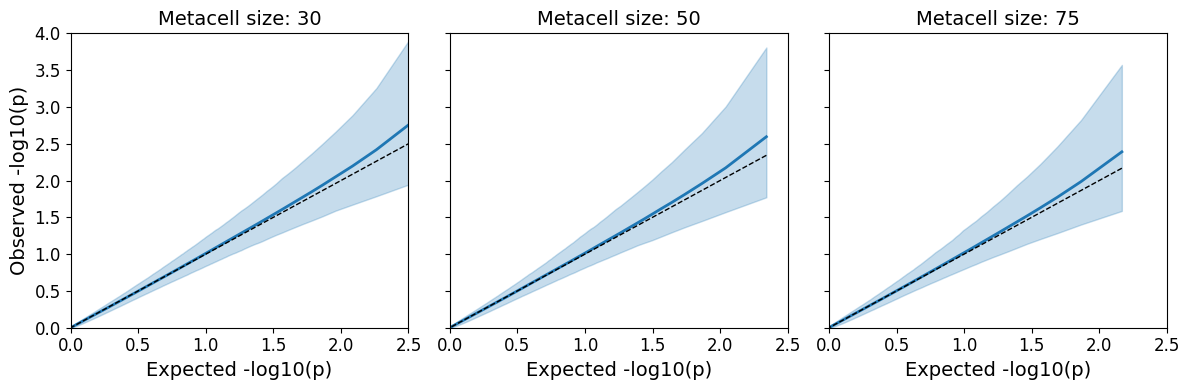

In [3]:
ncols = 3
fig, axes = plt.subplots(
    1, ncols,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

for ax, (label, mat) in zip(axes, mc_res.items()):
    M = mat.shape[1]

    # sort each row → empirical quantiles
    sorted_ppp = np.sort(mat, axis=1)
    obs = -np.log10(sorted_ppp)
    exp = -np.log10(np.arange(1, M + 1) / (M + 1))

    # summary curves
    mean_curve = obs.mean(axis=0)
    lo = np.percentile(obs, 5, axis=0)
    hi = np.percentile(obs, 95, axis=0)

    # plot
    ax.plot(exp, mean_curve, color="#1f77b4", lw=2)
    ax.fill_between(exp, lo, hi, color="#1f77b4", alpha=0.25)
    ax.plot(exp, exp, "k--", lw=1)

    ax.set_xlim(0.0, 2.5)
    ax.set_ylim(0.0, 4.0)
    ax.tick_params(labelsize=12)

    ax.set_title(f"Metacell size: {label}", fontsize=14)

# shared labels
axes[0].set_ylabel("Observed -log10(p)", fontsize=14)
for ax in axes:
    ax.set_xlabel("Expected -log10(p)", fontsize=14)

plt.tight_layout()
plt.savefig("../paper/supp/mc_null.pdf")
plt.show()

## Cell type null

In [4]:
mc_size = [30, 50, 75]
ct_res = {}
for size in mc_size:
    dfs = []
    files = Path(f'/mnt/gs21/scratch/yuanhao5/icepop_null_mc-{size}').rglob('celltype*.csv')
    files = [str(file) for file in files]
    for file in tqdm(files, total=len(files)):
        df = pd.read_csv(file, header=0, index_col=0, usecols=["cell_type", "p"])
        dfs.append(df)
    ct_res[size] = np.asarray(pd.concat(dfs, axis=1), np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

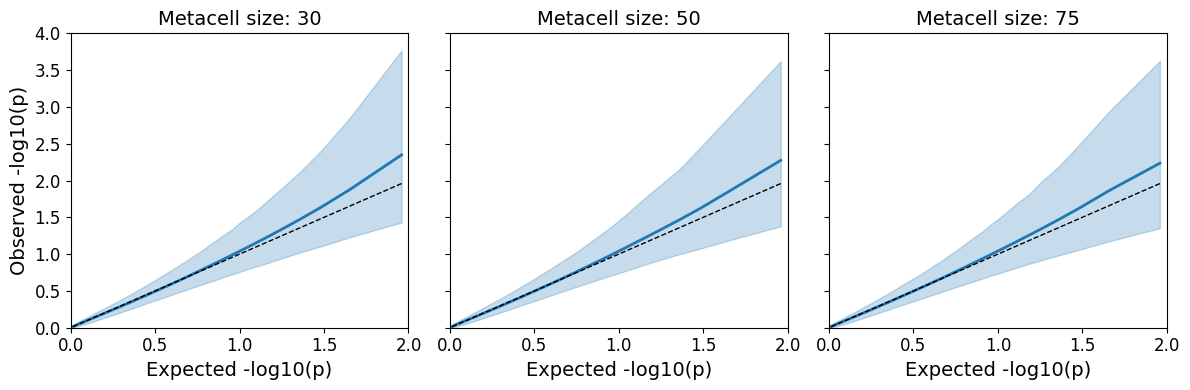

In [5]:
ncols = 3
fig, axes = plt.subplots(
    1, ncols,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

for ax, (label, mat) in zip(axes, ct_res.items()):
    M = mat.shape[1]

    # sort each row → empirical quantiles
    sorted_ppp = np.sort(mat, axis=1)
    obs = -np.log10(sorted_ppp)
    exp = -np.log10(np.arange(1, M + 1) / (M + 1))

    # summary curves
    mean_curve = obs.mean(axis=0)
    lo = np.percentile(obs, 5, axis=0)
    hi = np.percentile(obs, 95, axis=0)

    # plot
    ax.plot(exp, mean_curve, color="#1f77b4", lw=2)
    ax.fill_between(exp, lo, hi, color="#1f77b4", alpha=0.25)
    ax.plot(exp, exp, "k--", lw=1)
    ax.set_xlim(0.0, 2.0)
    ax.set_ylim(0.0, 4.0)
    ax.tick_params(labelsize=12)

    ax.set_title(f"Metacell size: {label}", fontsize=14)

# shared labels
axes[0].set_ylabel("Observed -log10(p)", fontsize=14)
for ax in axes:
    ax.set_xlabel("Expected -log10(p)", fontsize=14)

plt.tight_layout()
plt.savefig("../paper/supp/ct_null_mcsize.pdf")
plt.show()